In [41]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # visualization

import missingno as msno 

from sklearn.metrics import accuracy_score, roc_curve

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

## Load dataset

In [42]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

print("Train boyutu:", df_train.shape)
print("Test boyutu:", df_test.shape)

Train boyutu: (891, 12)
Test boyutu: (418, 11)


# EDA

## Temel bilgiler

In [43]:
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [44]:
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [45]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* Eğitim setindeki Survived sütununun ortalaması yaklaşık 0.384'tür. Bu, eğitim verisindeki yolcuların yaklaşık %38.4'ünün hayatta kaldığını, %61.6'sının ise hayatını kaybettiğini gösterir.

In [46]:
df_test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


* **Pclass (Bilet Sınıfı):** Yolcuların %75'inden fazlası 2. ve 3. sınıfta seyahat etmiştir. Ortalama bilet sınıfı 2.3 civarındadır.

* **Age (Yaş):** Yolcuların yaş ortalaması yaklaşık 29.7'dir. En genç yolcu 0.42 yaşında (bebek), en yaşlı yolcu ise 80 yaşındadır.

* **SibSp ve Parch (Aile Bilgileri):** Yolcuların büyük çoğunluğu (%50'den fazlası) gemide yalnız seyahat etmiştir (25%, 50% ve 75% çeyrekliklerinde bu değerler çoğunlukla 0 veya 1'dir). Maksimum kardeş/eş sayısı 8, ebeveyn/çocuk sayısı ise 9'dur.

* **Fare (Bilet Ücreti):** Ortalama ücret 32.20 birimdir. Ancak en yüksek bilet ücreti 512.32'dir. Standart sapmanın yüksek olması ve maksimum değerin büyüklüğü, veri setinde bilet ücreti açısından çok yüksek değerli (aykırı) birkaç yolcu olduğunu gösterir.

In [47]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [48]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


* **Age (Yaş):** Eğitim setinde 177 satır, test setinde ise 86 satır eksiktir.

* **Cabin (Kabin):** Her iki veri setinde de çok yüksek oranda eksiklik vardır (Eğitimde 204/891 dolu, Testte 91/418 dolu). Verinin yaklaşık %77'si boştur.

* **Embarked (Binilen Liman):** Eğitim setinde sadece 2 satır eksiktir. Test setinde eksik yoktur.

* **Fare (Bilet Ücreti):** Eğitim setinde eksik yoktur, test setinde sadece 1 satır eksiktir.

## Dependent Variable Analysis

In [49]:
d = pd.DataFrame(df_train["Survived"].value_counts())

d_clean = d.reset_index()

In [50]:
# Grafik çizimi (Sütun adlarını güncellenmiş yeni DataFrame'e göre ayarlıyoruz)
fig = px.pie(d_clean,       
             values="count",         # Pandas'ın oluşturduğu sayıların olduğu sütun
             names="Survived",     # Reset_index sonrası oluşan kategori sütunu (0 ve 1'ler)
             hole = 0.35,      
             opacity = 0.8,
             labels = {"count": "Number of Samples", "Survived": "Status"}
            )

fig.update_layout(title = dict(text = "Pie Chart of Survived Feature", x=0.5))
fig.update_traces(
    textposition = "outside", 
    textinfo = "percent+label", 
    labels = ["Not Survived", "Survived"]  # Sırasıyla 0 ve 1 değerlerini bu metinlerle eşler
)
fig.show()

Grafik, hafif bir sınıf dengesizliği (light class imbalance) olduğunu gösteriyor. Örneklerin çoğunluğu (neredeyse 3'te 2'si) hayatını kaybeden yolculardan oluşuyor.

## Korelasyon Analysis

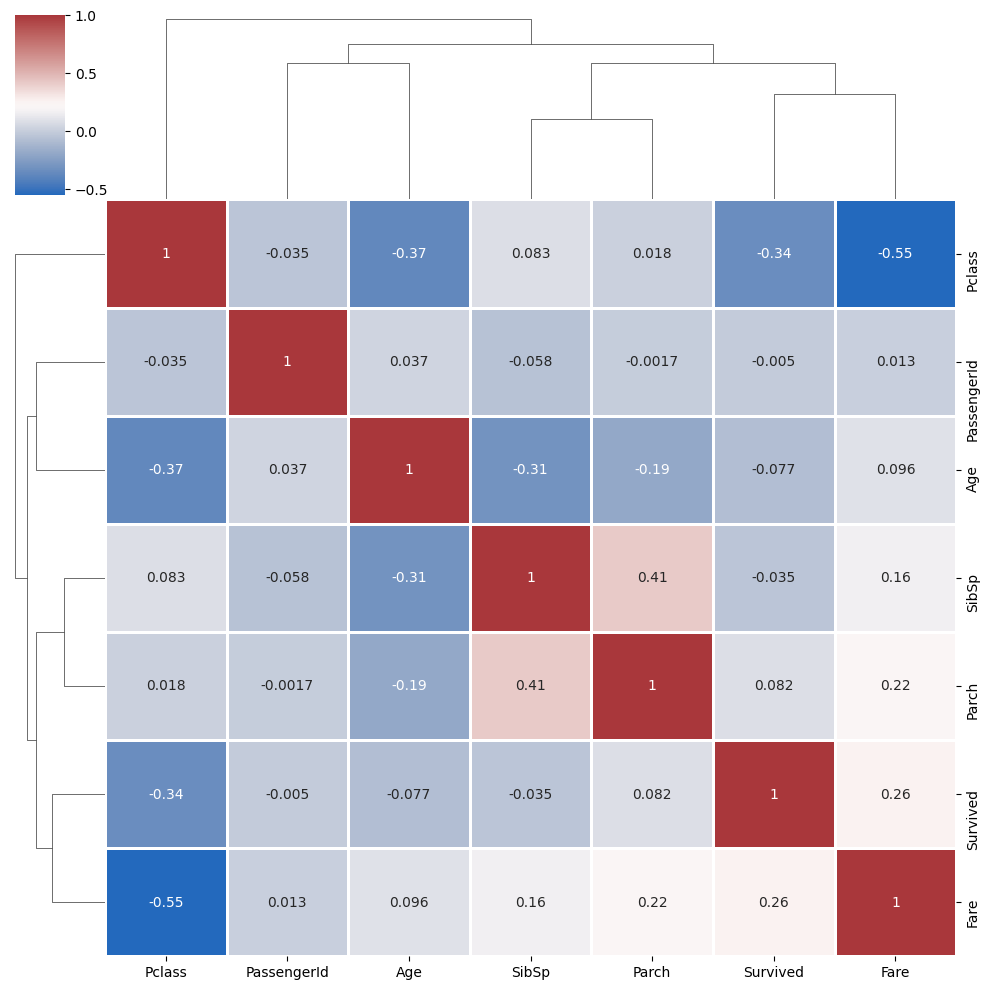

In [51]:
sns.clustermap(
    df_train.corr(numeric_only=True), 
    cmap = "vlag", 
    dendrogram_ratio = (0.1,0.2),
    annot = True, 
    linewidths = 0.8,
    figsize = (10,10)
)
plt.show()

* *Hedef Değişken ('Survived') ile İlişkiler*
    * **Fare (Bilet Ücreti) ile İlişkisi (+0.26):** Bu durum, biletine daha fazla ücret ödeyen yolcuların (üst kamara/birinci sınıf) hayatta kalma oranının daha yüksek olduğunu gösterir.
    
    * **Pclass (Bilet Sınıfı) ile İlişkisi (-0.34):** Sınıf numarası arttıkça (1'den 3'e doğru gittikçe, yani sosyo-ekonomik durum düştükçe) hayatta kalma ihtimali belirgin bir şekilde azalmıştır.
    
    * **Age (Yaş) ile İlişkisi (-0.077):**  Genel olarak yaş arttıkça hayatta kalma oranı çok küçük bir miktar düşmüş görünse de, bu doğrusal ilişki tek başına çok zayıftır (çocuklar ve yaşlılar ayrımı doğrusal olmadığı için modelleme aşamasında derinleşecektir).
    
    * **SibSp (-0.035) ve Parch (+0.082):** Gemiye tek başına binmek yerine ebeveyn/çocukla (Parch) binmiş olmak hayatta kalmayı çok hafif pozitif etkilerken, çok fazla kardeş/eşe (SibSp) sahip olmak hafif negatif etkilemiş.

* *Diğer Değişkenlerin Kendi Aralarındaki Güçlü İlişkiler*
    * **Pclass ve Fare (-0.55):** Negatif yönlüdür çünkü bilet sınıfı numarası küçüldükçe (1. sınıfa doğru gittikçe) ödenen bilet ücreti (Fare) doğal olarak belirgin şekilde artmaktadır.
    
    * **Pclass ve Age (-0.37):** 1. sınıftaki yolcuların yaş ortalamasının, 3. sınıftaki yolculara göre daha yüksek (yaşça daha büyük) olduğunu gösterir.
    
    * **SibSp ve Parch (+0.41):** Gemiye ailesiyle binen yolcular genellikle hem kardeş/eş (SibSp) hem de ebeveyn/çocuk (Parch) bilgilerine birlikte sahiptir (örneğin çocuklu aileler).

* *Tamamen Etkisiz Değişken*
    * **PassengerId:** Survived ile olan ilişkisi neredeyse sıfırdır (-0.005). Yolcuların sisteme kayıt sıra numarası tamamen rastgele olduğu için hayatta kalma üzerinde hiçbir etkisi yoktur ve model eğitilirken bu sütun düşülmelidir (drop edilmelidir).

## categorical and numerical feature analysis

### numerical

In [52]:
non_survived = df_train.query("Survived == 0")
survived = df_train.query("Survived == 1")

In [53]:
numerical_cols = df_train.select_dtypes(include=['number']).columns
numerical_cols = [col for col in numerical_cols if col not in ['Survived', 'PassengerId']]

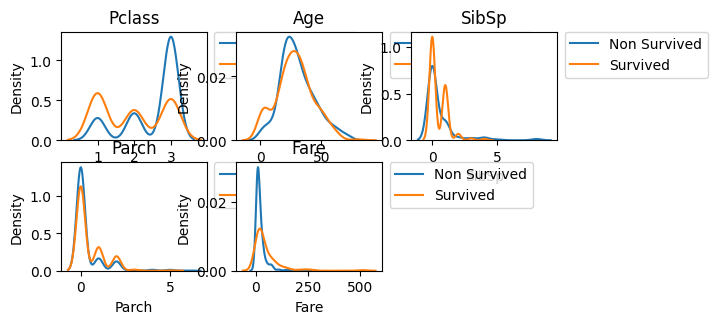

In [54]:
for ax, col in enumerate(numerical_cols):
    plt.subplot(3, 3, ax + 1)
    plt.title(col)

    sns.kdeplot(x = non_survived[col], label = "Non Survived")
    sns.kdeplot(x = survived[col], label = "Survived")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() 
plt.show()

* *Pclass (Bilet Sınıfı) Analizi*
    * **Mavi Çizgi (Ölenler):** En büyük patlamayı (tepe noktasını) 3. sınıfta yapmış. Yani 3. sınıftaki yolcuların ezici bir çoğunluğu hayatını kaybetmiş.
    
    * **Turuncu Çizgi (Kurtulanlar):** En yüksek tepe noktası 1. sınıfta. Bu da bilet sınıfı kalitesi arttıkça hayatta kalma şansının belirgin bir şekilde yükseldiğini netçe gösteriyor.

* *Age (Yaş) Analizi*
    * Grafiğin sol tarafına (0-10 yaş arasına) dikkat, turuncu çizginin (kurtulanlar) mavi çizginin epey üzerinde bir çıkıntı yaptığını görülebilir. Bu, kazada çocuklara öncelik tanındığını ve çocukların hayatta kalma oranının daha yüksek olduğunu kanıtlar.
    * Orta yaş ve sonrasında ise çizgiler birbirine oldukça yakın seyrediyor.

* *SibSp ve Parch (Aile Bilgileri) Analizi* 
    * Her iki grafikte de en büyük yoğunluk 0 noktasında. Yani yolcuların çoğu tek başına seyahat ediyordu.
    * Ancak SibSp (Kardeş/Eş) grafiğinde 1 veya 2 yakını olanların (turuncu tepe), hiç yakını olmayanlara kıyasla hayatta kalma oranında hafif bir avantajı olduğu görülüyor. Çok kalabalık ailelerde ise turuncu çizgi neredeyse sıfıra inmiş.

* *Fare (Bilet Ücreti) Analizi*
    * Grafiğin neredeyse tamamı 0-100 birim ücret arasında sıkışmış durumda. Mavi çizgi (ölenler) sıfıra çok yakın, yani ucuz bilet alanlarda yoğunlaşmış.
    * Bilet ücreti sağa doğru arttıkça (100-250+ aralığı), mavi çizgi tamamen sıfıra yaklaşırken turuncu çizgi daha yukarıda kalıyor. Yani yüksek ücret ödeyenlerin kurtulma oranı bariz şekilde daha fazla. Ayrıca grafik çok uzun bir sağ kuyruğa sahip, bu da Fare sütununda aykırı değerler olduğunu teyit ediyor.

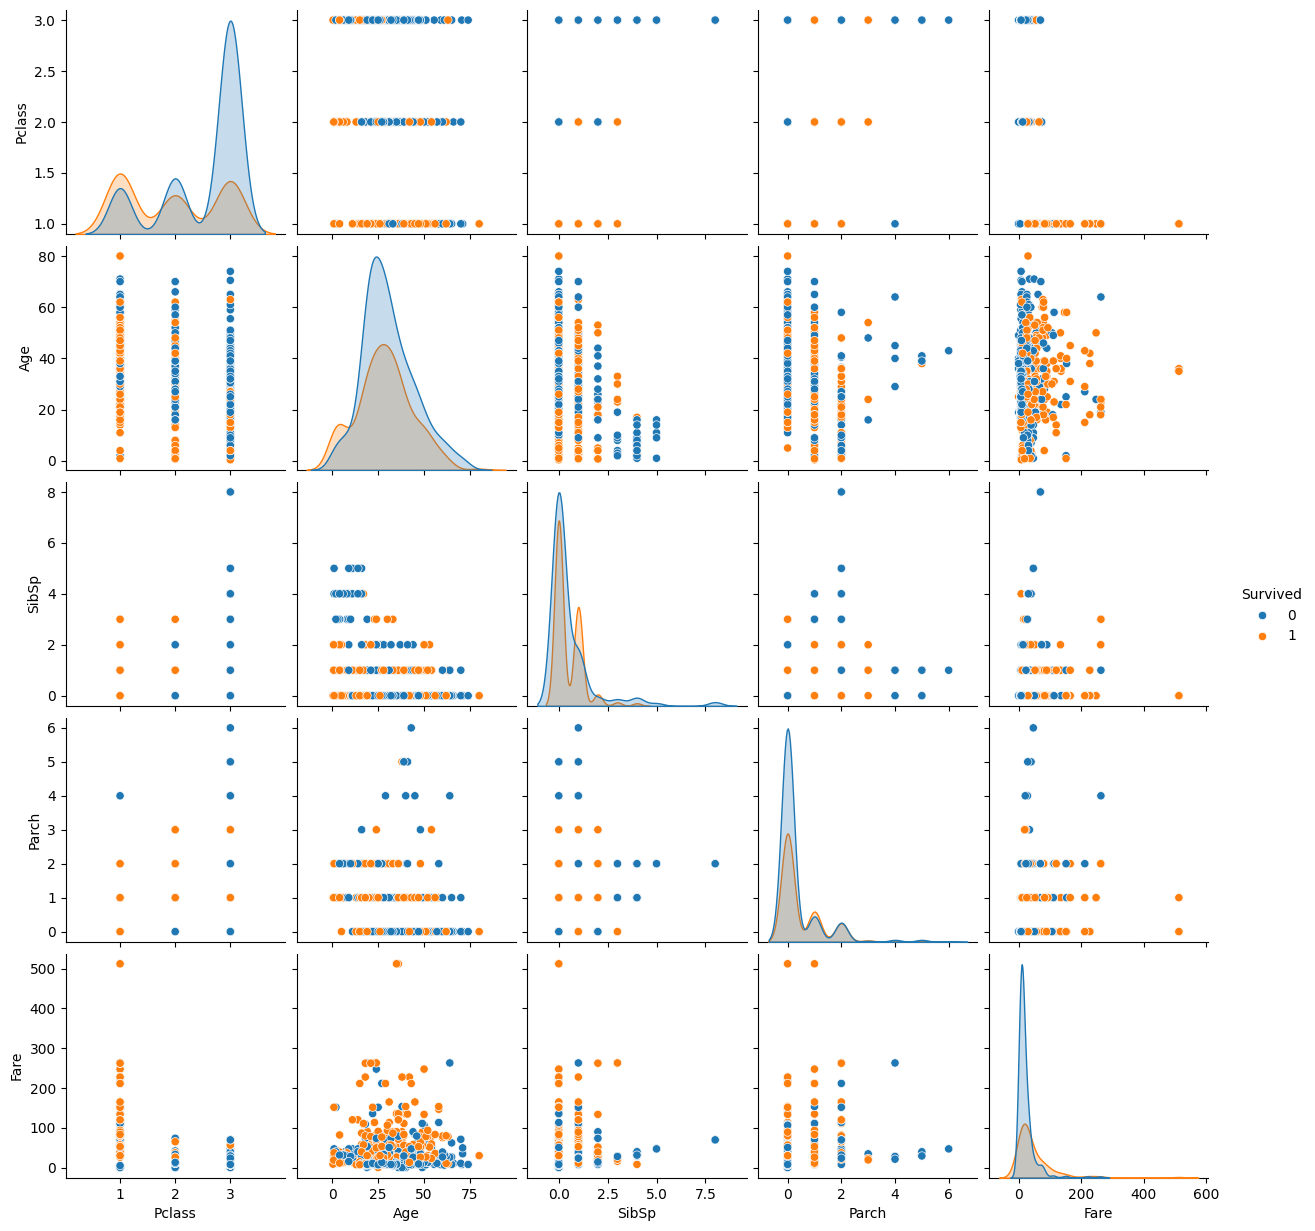

In [55]:
if "Survived" not in numerical_cols:
    df_numeric = df_train.loc[:, list(numerical_cols) + ["Survived"]]
else:
    df_numeric = df_train.loc[:, numerical_cols]

sns.pairplot(df_numeric, hue="Survived", diag_kind = "kde")
plt.show()

Grafiğin sol üstten sağ alta doğru inen köşegenleri, değişkenlerin kendi içindeki dağılımını gösterir (az önceki yoğunluk grafiklerinin aynısıdır):
* **Pclass (En sol üst):** 3. sınıfta mavilerin (ölenlerin) nasıl devasa bir tepe yaptığını, 1. sınıfta ise turuncuların (kurtulanların) daha baskın olduğunu buradan da görebiliyoruz.
* **Fare (En sağ alt):** Düşük ücretlerde mavi tepe çok yüksekken, bilet ücreti sağa doğru uzadıkça turuncu çizginin daha üstte kaldığı net bir şekilde seçiliyor.

* *İki Değişkenin Kesişimleri (Serpme / Scatter Plot Grafikleri)*
    * **Age vs Fare:** Grafiğin en altında (ucuz biletlerde) her yaştan yoğun bir mavi nokta kümesi var. 
    Ancak bilet ücreti ekseninde yukarı doğru çıktıkça (Fare > 200), noktaların neredeyse tamamen turuncuya döndüğünü görünüyor. Yani yaşınız kaç olursa olsun, çok pahalı bilet aldıysanız kurtulma şansınız ciddi derecede artmış.

    * **Pclass vs Age:** 1 sınıfına (Pclass = 1) baktığında noktalar yukarıya (yaşlılara) doğru daha yoğun yayılmış.
    3 sınıfına (Pclass = 3) baktığında ise noktalar aşağıda (genç ve çocuk yaşlarda) çok daha sıkışık. Buna rağmen 3. sınıftaki çocuk yaş grubunda bile mavi noktaların (ölenlerin) yoğunluğu dikkat çekiyor.
    * **SibSp vs Parch:**
        * Noktaların büyük kısmı (0,0) noktasında, yani tamamen yalnız olanlarda toplanmış ve burada maviler çoğunlukta.
        * Küçük aile yapılarında (1-2 akraba) turuncular biraz daha dağılmışken, akraba sayısı çok yükseldikçe (grafiğin uç sınırları) noktalar yine maviye dönüyor.


### categorical

In [56]:
categorical_cols = df_train.select_dtypes(include=['object']).columns
# Çok fazla benzersiz değere sahip olan Name, Ticket ve Cabin sütunlarını 
# bu grafikler için eliyoruz (grafiği bozmamaları için)
categorical_cols = [col for col in categorical_cols if col not in ['Name', 'Ticket', 'Cabin']]

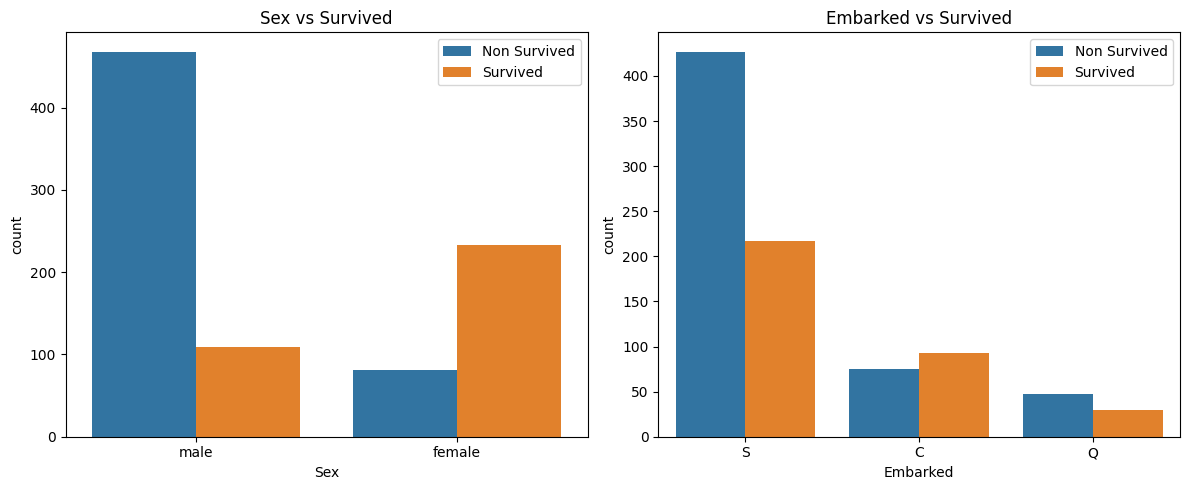

In [57]:
plt.figure(figsize=(12, 5))

for ax, col in enumerate(categorical_cols):
    plt.subplot(1, 2, ax + 1)
    plt.title(f"{col} vs Survived")
    
    # countplot ile Survived durumuna göre kaç kişi olduğunu saydırıyoruz
    sns.countplot(data=df_train, x=col, hue='Survived')
    plt.legend(labels=["Non Survived", "Survived"])

plt.tight_layout()
plt.show()

* *Sex (Cinsiyet) vs Survived Analizi*
    * **Erkekler (male):** Gemiye binen erkek sayısı çok yüksek olmasına rağmen (mavi sütun 450'nin üzerinde), hayatta kalan erkek sayısı (turuncu sütun) 100 civarında kalmış. Yani erkeklerin ezici bir çoğunluğu hayatını kaybetmiş.
    
    * **Kadınlar (female):** Gemiye binen kadın sayısı erkeklere göre daha az olmasına rağmen, hayatta kalan kadın sayısı (turuncu sütun) ölenlerin (mavi sütun) neredeyse 3 katı.
    
    * Tahliye sırasında uygulanan "Önce kadınlar ve çocuklar" kuralı burada kendini açıkça gösteriyor. Sex değişkeni, modelin yolcuları tahmin ederken kullanacağı en güçlü ve en ayırt edici özellik (feature) olacak.

* *Embarked (Binilen Liman) vs Survived Analizi*
    * **S (Southampton):** Yolcuların çok büyük bir kısmı bu limandan gemiye binmiş. Ancak bu limandan binenlerin yaklaşık 3'te 2'si hayatını kaybetmiş (mavi sütun 400'ün üzerinde, turuncu sütun 200 civarı).
    * **C (Cherbourg):** Bu limanın grafiğinde çok özel bir durum var: Turuncu sütun (kurtulanlar), mavi sütundan (ölenler) daha yüksek. Yani Cherbourg'dan binen yolcuların yarıdan fazlası hayatta kalmayı başarmış. (Tarihsel not: Bu limandan binen yolcuların büyük kısmı zengin, yani 1. sınıf yolculardı.)
    * **Q (Queenstown):** Genel olarak yolcu sayısı az ve binenlerin çoğunluğu yine hayatını kaybetmiş.

## Missing value

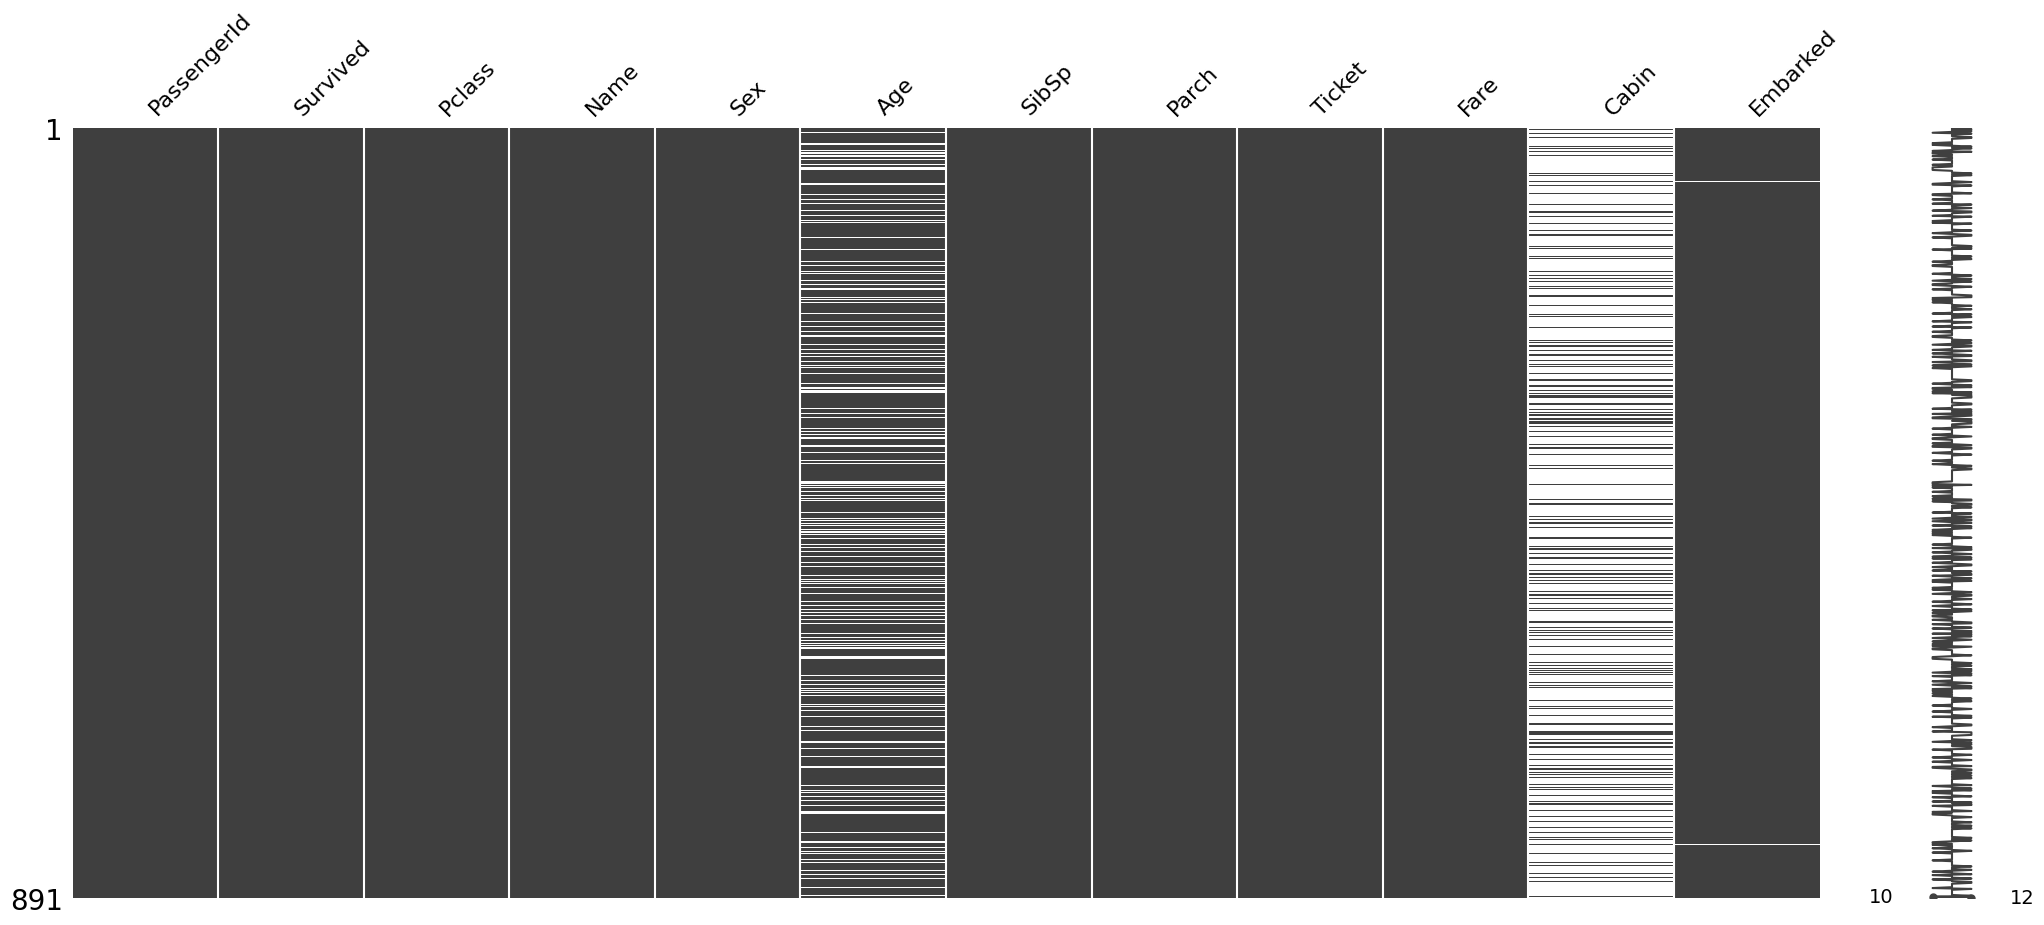

In [58]:
msno.matrix(df_train)
plt.show()

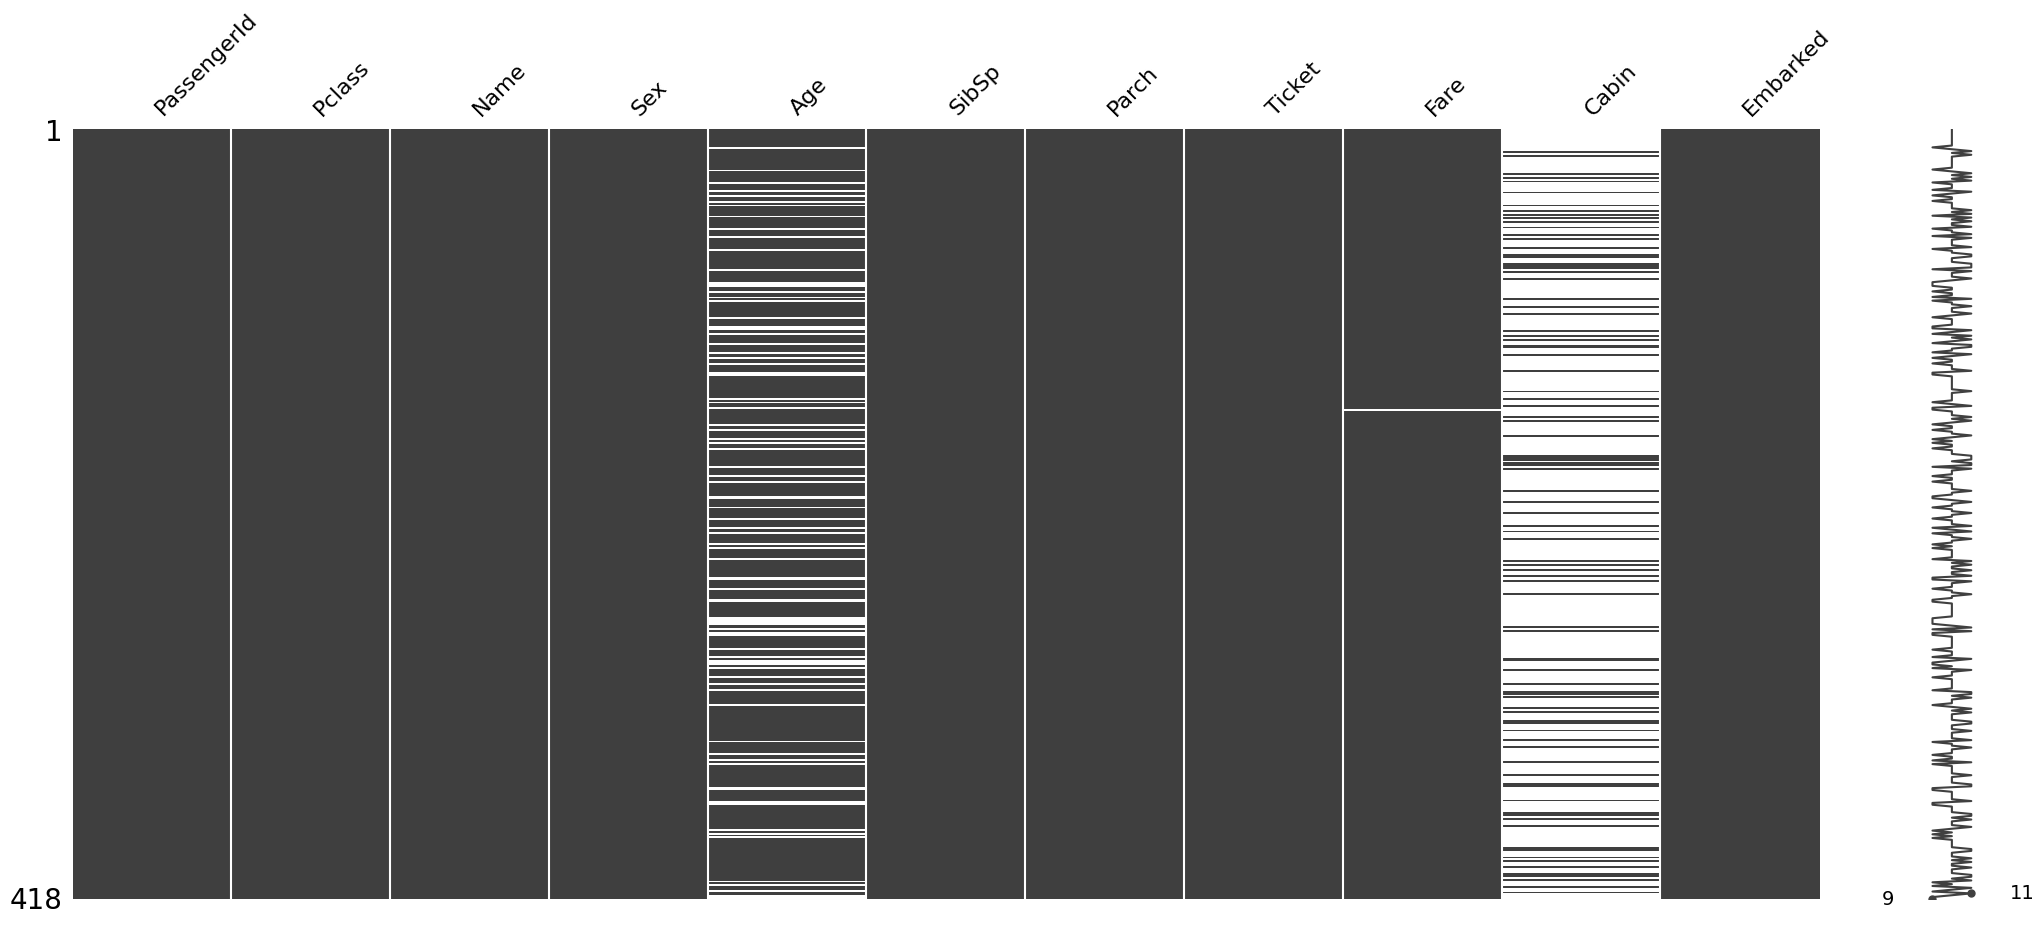

In [59]:
msno.matrix(df_test)
plt.show()

Age (Yaş) 177 train / 86 test eksik, 

Cabin (Kabin) sütununun ise verinin yaklaşık %77'sini kapsayacak şekilde neredeyse tamamen beyaz bir blok halinde boş olduğunu netçe görebiliyoruz; 

eğitim setinde Embarked sütununda sadece 2, 

test setinde ise Fare (Bilet Ücreti) sütununda nokta atışı sadece 1 eksik değer bulunurken, 

geriye kalan tüm sütunlar tamamen dolu ve temiz bir yapı sergiliyor.

# Preprocessing

## Missing Values

**Embarked (Binilen Liman)**

Eğitim setinde sadece 2 adet eksik veri var.

Bu iki eksik satırı, veri setinde en çok tekrar eden (Mod değeri olan) liman ile dolduracağız. Grafiklerden de gördüğümüz gibi en çok tekrar eden liman "S" (Southampton).

In [60]:
train_embarked_mode = df_train['Embarked'].mode()[0]
train_embarked_mode 

'S'

In [61]:
df_train['Embarked'] = df_train['Embarked'].fillna(train_embarked_mode)
df_test['Embarked'] = df_test['Embarked'].fillna(train_embarked_mode)

**Fare (Bilet Ücreti)**

Test setinde sadece 1 adet eksik veri var.

Tüm veri setinin ortalamasını almak yerine, bu eksik bilet ücretine sahip yolcunun bilet sınıfına (Pclass) bakarız. Örneğin yolcu 3. sınıftaysa, eğitim setindeki 3. sınıf yolcularının bilet ücreti medyanını bulup bu tek boşluğa yazarız.

In [62]:
pclass_fare_medians = df_train.groupby('Pclass')['Fare'].median()
pclass_fare_medians

Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

In [63]:
# Train setinde Fare eksik olmadığı için sadece test setindeki o 1 eksik satırı doldur
df_test['Fare'] = df_test.apply(
    lambda row: pclass_fare_medians[row['Pclass']] if pd.isna(row['Fare']) else row['Fare'], 
    axis=1
)

**Age (Yaş)**

Hem train hem test setinde toplamda 260'tan fazla eksik var.

Herkese düz bir yaş ortalaması vermek yapay zekayı yanıltır. Bunun yerine, yolcuların isimlerindeki (Name) unvanları (Mr, Mrs, Miss, Master) çekip, her unvan grubunun kendi yaş medyanını hesaplayarak boşlukları dolduracağız. (Örneğin "Master" unvanlı bir çocuğa genel ortalama olan 29 yaşını vermek yerine, çocukların yaş medyanı olan 4-5 yaşını vermiş olacağız).

In [64]:
df_train['Title'] = df_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_test['Title'] = df_test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

for df in [df_train, df_test]:
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

title_age_medians = df_train.groupby('Title')['Age'].median()
title_age_medians

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

In [65]:
df_train['Age'] = df_train.apply(
    lambda row: title_age_medians[row['Title']] if pd.isna(row['Age']) else row['Age'], 
    axis=1
)

In [66]:
df_test['Age'] = df_test.apply(
    lambda row: title_age_medians[row['Title']] if pd.isna(row['Age']) else row['Age'], 
    axis=1
)

**Cabin (Kabin)**

Verinin %77'si boş olduğu için doldurmak mantıksızdır.

Bu sütunu ya tamamen düşüreceğiz (drop) ya da "Kabin numarası var: 1, yok: 0" şeklinde ikili bir özelliğe çevireceğiz.

In [67]:
# Doğrudan işimize yaramayan ve çok fazla boşluğu olan sütunları siliyoruz
columns_to_drop = ['Name', 'Ticket', 'Cabin']

df_train = df_train.drop(columns=columns_to_drop)
df_test = df_test.drop(columns=columns_to_drop)

In [68]:
print("Gereksiz sütunlar başarıyla temizlendi!")
print("Train kalan sütunlar:", df_train.columns.tolist())
print("Test kalan sütunlar:", df_test.columns.tolist())

Gereksiz sütunlar başarıyla temizlendi!
Train kalan sütunlar: ['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']
Test kalan sütunlar: ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']


In [69]:
print("--- TRAIN SETİ EKSİK KONTROLÜ ---")
print(df_train.isnull().sum())
print("\n--- TEST SETİ EKSİK KONTROLÜ ---")
print(df_test.isnull().sum())

--- TRAIN SETİ EKSİK KONTROLÜ ---
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          0
dtype: int64

--- TEST SETİ EKSİK KONTROLÜ ---
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          0
dtype: int64


eksik veri kalmamıştır.

## Encoding

In [70]:
# Label Encoding → Kadın: 1, Erkek: 0
df_train['Sex'] = df_train['Sex'].map({'female': 1, 'male': 0})
df_test['Sex'] = df_test['Sex'].map({'female': 1, 'male': 0})

In [81]:
if 'Embarked' in df_train.columns:
    df_train = pd.get_dummies(df_train, columns=['Embarked'], drop_first=True, dtype=int)

if 'Embarked' in df_test.columns:
    df_test = pd.get_dummies(df_test, columns=['Embarked'], drop_first=True, dtype=int)

In [92]:
if 'Title' in df_train.columns:
    df_train = pd.get_dummies(df_train, columns=['Title'], drop_first=True, dtype=int)

if 'Title' in df_test.columns:
    df_test = pd.get_dummies(df_test, columns=['Title'], drop_first=True, dtype=int)

In [93]:
print("--- TRAIN VERİ TİPLERİ VE GÜNCEL SÜTUNLAR ---")
print(df_train.dtypes)

--- TRAIN VERİ TİPLERİ VE GÜNCEL SÜTUNLAR ---
PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_Q       int64
Embarked_S       int64
Title_Miss       int64
Title_Mr         int64
Title_Mrs        int64
Title_Rare       int64
dtype: object


## Sütun Eşitleme

In [94]:
# Train setinden hedef değişkeni (Survived) ayır
X_train = df_train.drop(columns=['Survived', 'PassengerId'])
y_train = df_train['Survived']

In [95]:
# Test setinden ID sütununu ayır (Tahmin için sadece özellikler kalmalı)
X_test = df_test.drop(columns=['PassengerId'])

In [96]:
# Test setinde eksik sütun kalıp kalmadığını train setine göre hizalayarak kontrol et
# Eğer test setinde eksik sütun varsa otomatik 0 ile doldurulur, fazla sütun varsa atılır
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [97]:
print("X_train boyutu:", X_train.shape)
print("X_test boyutu:", X_test.shape)
print("\nSütunlar birebir eşitlendi mi?:", list(X_train.columns) == list(X_test.columns))

X_train boyutu: (891, 12)
X_test boyutu: (418, 12)

Sütunlar birebir eşitlendi mi?: True


## Standardization

In [98]:
scaler = StandardScaler()
cols_to_scale = ['Age', 'Fare']

X_train_scaled = X_train.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Modelling

In [99]:
log_reg = LogisticRegression(
    max_iter=1000, 
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=42
)

In [100]:
models = {
    "Logistic Regression": (log_reg, X_train_scaled),
    "Random Forest": (rf, X_train) # Ağaç modeli olduğu için orijinal X_train yeterli
}

In [101]:
best_score = 0
best_model_name = ""

In [102]:
print("--- MODEL SKORLARI (5-Fold Cross Validation Accuracy) ---")
for name, (model, X_data) in models.items():
    scores = cross_val_score(model, X_data, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    print(f"{name}: %{mean_score*100:.2f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_model_name = name

--- MODEL SKORLARI (5-Fold Cross Validation Accuracy) ---
Logistic Regression: %82.38
Random Forest: %82.38


In [103]:
rf.fit(X_train, y_train)

# 2. Test seti üzerinden hayatta kalma tahminlerini yapıyoruz
predictions = rf.predict(X_test)

# 3. Kaggle'ın istediği formatta bir DataFrame oluşturuyoruz
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": predictions
})

In [104]:
submission.to_csv("submission.csv", index=False)

print("Tahminler başarıyla yapıldı ve 'submission.csv' dosyası kaydedildi! 🚀")
print(submission.head())

Tahminler başarıyla yapıldı ve 'submission.csv' dosyası kaydedildi! 🚀
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
